# Continuous Control

---

You are welcome to use this coding environment to train your agent for the project.  Follow the instructions below to get started!

### 0. Clean Up the Zombie Processes
At the end of this notebook, when you execute `env.close()`, it does not clean up the environment completely. Instead, the Unity environment process becomes a "zombie" process. A zombie process is one that has completed execution but still has an entry in the process table because its parent process hasn’t properly reaped it.
You can yourself verify this by running these commands in the terminal. Find the parent process ID (PPID) of the zombie process:
```bash
ps -o pid,ppid,stat,cmd | grep Reacher
```
If the parent process (PPID) is not 1, kill it to clean up the zombie process:
```bash
kill -9 <PPID>
```
Below is the equivalent Python code that checks for and cleans zombie processes using `psutil`. **You need run the cell below only when you restart the Unity environment.** 

> **NOTE**: The code cell below will also kill the Kernel. You should restart it when required.

### 1. Start the Environment

Run the next code cell to install a few packages.  This line will take a few minutes to run!

In [14]:
import sys
!{sys.executable} -m pip install -q .
!{sys.executable} -m pip install torch protobuf==3.19.0 numpy==1.26.4

I0000 00:00:1753710355.981428  323579 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


  DEPRECATION: Building 'unityagents' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'unityagents'. Discussion can be found at https://github.com/pypa/pip/issues/6334


I0000 00:00:1753710357.524721  323579 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


In [15]:
!pip -q uninstall . -y
!pip uninstall torch protobuf numpy -y

I0000 00:00:1753710358.144074  323579 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


ERROR: You must give at least one requirement to uninstall (see "pip help uninstall")


I0000 00:00:1753710358.726704  323579 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


  Obtaining dependency information for nvidia-nvtx-cu12==12.6.77 from https://files.pythonhosted.org/packages/56/9a/fff8376f8e3d084cd1530e1ef7b879bb7d6d265620c95c1b322725c694f4/nvidia_nvtx_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for nvidia-nvjitlink-cu12==12.6.85 from https://files.pythonhosted.org/packages/9d/d7/c5383e47c7e9bf1c99d5bd2a8c935af2b6d705ad831a7ec5c97db4d82f4f/nvidia_nvjitlink_cu12-12.6.85-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata
  Obtaining dependency information for nvidia-cufile-cu12==1.11.1.6 from https://files.pythonhosted.org/packages/b2/66/cc9876340ac68ae71b15c743ddb13f8b30d5244af344ec8322b449e35426/nvidia_cufile_cu12-1.11.1.6-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for triton==3.3.1 from https://files.pythonhosted.org/packages/21/2f/3e56ea7b58f80ff68899b1dbe810ff257c9d177d288c6b0f55bf2fe4eb50/triton-3.3.1-cp311


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


The environments corresponding to both versions of the environment are already saved in the Workspace and can be accessed at the file paths provided below.  

Please select one of the two options below for loading the environment.

In [16]:
from unityagents import UnityEnvironment
import numpy as np

# select this option to load version 1 (with a single agent) of the environment
env = UnityEnvironment(file_name='/data/Reacher_One_Linux_NoVis/Reacher_One_Linux_NoVis.x86_64')

# select this option to load version 2 (with 20 agents) of the environment
# env = UnityEnvironment(file_name='/data/Reacher_Linux_NoVis/Reacher.x86_64')

UnityEnvironmentException: Couldn't launch the Reacher_One_Linux_NoVis environment. Provided filename does not match any environments.

Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [ ]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

Run the code cell below to print some information about the environment.

In [ ]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agent and receive feedback from the environment.

Note that **in this coding environment, you will not be able to watch the agents while they are training**, and you should set `train_mode=True` to restart the environment.

In [ ]:
env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
states = env_info.vector_observations                  # get the current state (for each agent)
scores = np.zeros(num_agents)                          # initialize the score (for each agent)
while True:
    actions = np.random.randn(num_agents, action_size) # select an action (for each agent)
    actions = np.clip(actions, -1, 1)                  # all actions between -1 and 1
    env_info = env.step(actions)[brain_name]           # send all actions to tne environment
    next_states = env_info.vector_observations         # get next state (for each agent)
    rewards = env_info.rewards                         # get reward (for each agent)
    dones = env_info.local_done                        # see if episode finished
    print(dones)
    scores += env_info.rewards                         # update the score (for each agent)
    states = next_states                               # roll over states to next time step
    print(scores)
    print(states)
    if np.any(dones):                                  # exit loop if episode finished
        break
print('Total score (averaged over agents) this episode: {}'.format(np.mean(scores)))

[False]
[0.]
[[-1.80081749 -3.46909928 -0.87030774  0.96589392 -0.22844657 -0.02804322
  -0.11863719 -1.61859596 -0.02118625  0.07451478  0.27829525 -1.72514653
   5.55457926 -3.37276077 -9.06182671 -1.36789763  0.9965896  -0.03945327
  -0.06886008  0.02260233  1.10818589 -1.34343338 -0.31153536 -1.34339225
  -3.28788686  4.38087606  1.65815735 -1.         -7.82627058  0.
   1.          0.         -0.53301406]]
[False]
[0.]
[[-1.84237480e+00 -3.52615070e+00 -4.48360473e-01  9.69880044e-01
  -2.35325158e-01 -1.48685211e-02 -6.11044690e-02 -1.35826671e+00
   4.86483350e-02 -3.15172851e-01 -1.14346766e+00 -1.68798432e-01
   4.90182543e+00 -3.39388847e+00 -9.16756058e+00 -8.27538371e-01
   9.99155819e-01 -2.91712712e-02 -2.77527869e-02 -8.15973524e-03
   4.54509467e-01 -8.33260357e-01  6.23260140e-01  7.90515423e-01
  -4.82740164e-01  6.27448606e+00  1.94817162e+00 -1.00000000e+00
  -7.75916386e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.]
[[-1.880863

[False]
[0.]
[[ 6.29425049e-04 -2.97250438e+00  2.68479919e+00  9.33900237e-01
   6.87236898e-05 -3.83581501e-05  3.57533902e-01  1.75260335e-01
   4.31020886e-01  4.77021635e-01  2.58452225e+00 -4.96505171e-01
  -5.00941932e-01 -1.31317711e+00 -7.34385681e+00  6.33343983e+00
   9.22526062e-01 -2.12950781e-01  7.18901306e-02  3.13734710e-01
   6.57435894e-01 -4.69326556e-01 -6.53100967e-01  1.27051735e+00
  -1.27918458e+00 -3.84263539e+00  6.84783173e+00 -1.00000000e+00
  -4.13608503e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.]
[[ 1.34624481e-01 -2.97839713e+00  2.67440891e+00  9.34287429e-01
   1.56485215e-02 -5.96355274e-03  3.56127381e-01 -4.22242768e-02
   1.98822320e-01  2.23271906e-01  1.20141900e+00  1.37613013e-01
   1.04663901e-01 -1.17057991e+00 -7.43980885e+00  6.11421490e+00
   9.30689394e-01 -2.32444376e-01  6.53401390e-02  2.74804592e-01
   1.24007118e+00 -6.79269880e-02 -2.31641501e-01  1.19231582e+00
  -2.04257655e+00 -3.99617767e

[False]
[0.]
[[ 1.26611328e+00 -3.79297113e+00 -2.04208463e-01  9.86851156e-01
   1.59422785e-01  4.07161145e-03 -2.63182148e-02  1.57586896e+00
  -2.47565545e-02  1.17515326e+00  4.51965189e+00  1.51750207e+00
  -6.02884007e+00  8.58879089e-01 -9.21335030e+00 -1.14102817e+00
   9.58922207e-01 -2.20305979e-01 -8.65054652e-02 -1.56365722e-01
  -2.30501366e+00  6.93970621e-01 -3.13552880e+00 -5.20380020e+00
   4.98879433e+00 -3.81444275e-01  7.77433586e+00 -1.00000000e+00
   1.88671434e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.]
[[ 1.49377632 -3.65637112 -0.65362716  0.97814703  0.18847075  0.01652392
  -0.08622139  1.44029665 -0.09663817  0.65200353  2.47318769  1.73746729
  -5.20582724  0.78260612 -8.76595688 -1.45827103  0.94489014 -0.32079351
  -0.01797401 -0.06285806 -2.89315701 -1.21983433 -2.28691792 -3.15474677
   7.12482357 -1.81761241  7.69876385 -1.          2.1746347   0.
   1.          0.         -0.53301406]]
[False]
[0.]
[[ 1.630142

[False]
[0.]
[[-5.43304443e-01 -3.96258712e+00 -1.02068678e-01  9.97622430e-01
  -6.77186400e-02 -8.19410256e-04 -1.27720190e-02 -6.27531707e-01
  -2.87198052e-02  7.53539562e-01  2.99758625e+00 -5.49988866e-01
   2.47536421e+00  1.49215317e+00 -8.39953232e+00 -1.12816918e+00
   8.42103839e-01  4.20904100e-01  1.86325878e-01 -2.81040192e-01
  -2.30029702e+00  3.43180507e-01  6.34114444e-01  6.08906364e+00
  -2.08777380e+00  8.03354359e+00  4.19020462e+00 -1.00000000e+00
   6.81485033e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.]
[[-2.78736115e-01 -3.99077153e+00  4.72155362e-02  9.99381006e-01
  -3.46841924e-02  2.37761356e-04  5.88576309e-03 -3.90746504e-01
   3.48384888e-03  8.59257400e-01  3.44188404e+00 -2.92859733e-01
   1.56638110e+00  1.98372078e+00 -8.54045582e+00 -6.13109589e-01
   8.63655746e-01  4.51248288e-01  1.14007592e-01 -1.93587214e-01
  -3.04529858e+00  4.76413667e-01  4.36488688e-01  6.46071053e+00
  -2.37465549e+00  7.91267633e

[False]
[0.]
[[ 1.6410923  -2.43774605  2.7257514   0.89357388  0.19068889 -0.08480038
   0.39745745  0.22988601 -0.48132059 -0.42991439 -2.35466504 -1.35152316
   0.25403064  1.82254791 -6.9423933   3.87261534  0.9424203  -0.13604294
  -0.23834117 -0.1911276   0.07085896 -1.19860578  0.76069146  0.41319016
  -3.51735997 -1.80150318 -2.11359787 -1.          7.71574402  0.
   1.          0.         -0.53301406]]
[False]
[0.]
[[ 1.51573181 -2.58576751  2.66007352  0.90472907  0.17710304 -0.07440611
   0.38021523  0.66753608 -0.21380697 -0.20391679 -1.0975039  -2.10802126
  -1.38249457  1.76925278 -7.27348518  3.80331945  0.95616895 -0.11585312
  -0.20695291 -0.17172533 -0.85669887 -0.68333244  0.31769925  0.25693759
  -5.22367811  0.12852798 -2.39918137 -1.          7.63177061  0.
   1.          0.         -0.53301406]]
[False]
[0.]
[[ 1.41081619 -2.77464533  2.52288389  0.91839373  0.16645521 -0.06398106
   0.35320267  0.83240223 -0.26089263 -0.27940315 -1.43499041 -2.53496957
  -1.9081

...

[False]
[0.21]
[[-1.98312187 -3.39614654  0.75225246  0.96125728 -0.25358126  0.02749858
   0.10452244 -1.01902938 -0.13899879 -0.69926178 -2.51360607  2.05327415
   3.2549119  -1.84395981 -6.74833584 -1.08316994  0.38993213  0.60316414
  -0.69402677  0.04972912 -1.20303559 -0.02054862 -0.71885914 -5.08483934
  -2.46849513  7.02102232  7.98031044 -1.         -0.56093502  0.
   1.          0.         -0.53301406]]
[False]
[0.21]
[[-2.09481812 -3.26784945  0.98282528  0.95254642 -0.26780125  0.03914222
   0.13930476 -0.8464241  -0.0695383  -0.24782458 -0.88601285  1.30221713
   2.66070724 -2.12718773 -6.81241798 -0.62337089  0.38999045  0.56196034
  -0.72778255  0.04940312 -1.19647813  0.39383426 -0.33234265 -3.42810655
  -2.6732657   5.55542564  7.99565315 -1.         -0.2636947   0.
   1.          0.         -0.53301406]]
[False]
[0.21]
[[-2.16031075 -3.17188597  1.14329028  0.94587618 -0.27575177  0.04787793
   0.16427681 -0.56676447 -0.07768293 -0.22478412 -0.8087514   1.1116432
   1

[False]
[0.21]
[[-1.63351059e-01 -3.48094845e+00  1.96919632e+00  9.67163801e-01
  -1.96570382e-02  5.15373098e-03  2.53340125e-01  2.67702669e-01
  -8.24850202e-02 -1.44802973e-01 -6.69469953e-01 -5.10614097e-01
  -9.46809828e-01 -2.71365547e+00 -7.83481359e+00  3.16398978e+00
  -1.71877518e-02  6.02298081e-02 -8.88654530e-01 -4.54279870e-01
  -1.57031548e+00 -8.58743936e-02  2.29516387e-01 -5.41528344e-01
  -2.47953892e+00  2.04572916e+00  5.86227798e+00 -1.00000000e+00
   5.44368410e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.21]
[[-1.74247742e-01 -3.53032732e+00  1.87776196e+00  9.70332503e-01
  -2.10399125e-02  5.21972310e-03  2.40800530e-01  3.41492057e-01
   2.26013567e-02  4.20316271e-02  1.91662595e-01 -6.57005727e-01
  -1.20390379e+00 -2.72495270e+00 -7.95086765e+00  3.19625878e+00
   5.33404667e-03  1.27756707e-02 -8.91635954e-01 -4.52541471e-01
  -1.16221559e+00  8.44250098e-02 -5.95834665e-02  1.61946446e-01
  -1.15464926e+00  1.25697

[False]
[0.21]
[[ 6.96250916e-01 -3.74068213e+00 -1.24995780e+00  9.83413279e-01
   8.57356042e-02  1.41140772e-02 -1.59212455e-01  1.52109253e+00
   4.46576595e-01 -1.48236609e+00 -6.09699583e+00  5.05842805e-01
  -6.10388803e+00  1.17289925e+00 -9.52683544e+00 -1.67457414e+00
   4.37326171e-02 -8.44604746e-02 -9.95460451e-01 -3.50872823e-03
  -2.32156301e+00  6.21034205e-01  4.42963076e+00  9.26678181e+00
   7.86755309e-02 -1.07643314e-01 -2.66899109e-01 -1.00000000e+00
   7.99554682e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.21]
[[ 2.10102081e-01 -3.72380805e+00 -1.45344198e+00  9.82571304e-01
   2.56825686e-02  4.83871065e-03 -1.84039995e-01  3.10345680e-01
   5.01589537e-01 -1.30771446e+00 -5.61535311e+00  2.74093580e-02
  -1.32211745e+00  1.39331436e+00 -9.25359631e+00 -1.78490412e+00
  -6.58788299e-03 -1.28340140e-01 -9.76452231e-01  1.73281401e-01
  -1.08026206e+00  1.74172544e+00  4.08732224e+00  9.19408512e+00
   5.90907717e+00  2.15125

[False]
[0.21]
[[ 1.42653084 -3.67120576  0.71225917  0.9791314   0.17954738 -0.01722828
   0.09363605 -0.83358872 -0.11759248 -0.6691134  -2.54051161 -0.44914931
   3.24393201  4.92852497 -7.09341621  2.86125636 -0.1019586  -0.40943107
  -0.77514255  0.47023895 -1.48159325  0.20758782 -0.1573548  -4.10590744
   2.1826241   6.46988535 -5.82031822 -1.          5.48852396  0.
   1.          0.         -0.53301406]]
[False]
[0.21]
[[ 1.23446655 -3.65915656  1.05463266  0.97823578  0.15389578 -0.02170762
   0.13747598 -1.27914083 -0.1539024  -0.59354115 -2.33723211  0.46287683
   4.91694784  4.62090778 -7.07586575  3.41469693 -0.13173321 -0.41881654
  -0.7710399   0.46123382 -0.03128812  0.49709007 -0.52267051 -3.40307426
  -1.02388561  6.80203867 -6.02044296 -1.          5.26823235  0.
   1.          0.         -0.53301406]]
[False]
[0.21]
[[ 1.05524254 -3.58618903  1.43281162  0.97352171  0.13003446 -0.02495903
   0.18634266 -1.20149779 -0.19493103 -0.52706033 -2.17386818  1.03291023
   

[False]
[0.21]
[[-1.11166000e-01 -3.26110172e+00  2.32052803e+00  9.52915788e-01
  -1.31726060e-02  4.20324458e-03  3.02919656e-01  2.75465369e-01
  -3.16677690e-01 -4.42582935e-01 -2.18762636e+00 -6.14688218e-01
  -9.21764255e-01 -2.98731232e+00 -6.80130005e+00  3.94023871e+00
  -2.07483359e-02  3.68409902e-02 -8.25233221e-01 -5.63207269e-01
   2.65777564e+00 -4.00365621e-01  3.36288735e-02 -3.74912643e+00
  -1.08863199e+00 -7.57675171e+00 -7.99744225e+00 -1.00000000e+00
  -2.02295393e-01  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -5.33014059e-01]]
[False]
[0.21]
[[-0.32966995 -3.40111256  2.08808231  0.96188319 -0.03947799  0.01118677
   0.2703647   1.16565239 -0.39958984 -0.62144858 -2.96424794 -2.3614006
  -4.04167128 -3.35859489 -7.06599951  3.49140954  0.02248326  0.01584194
  -0.82745677 -0.56085533 -1.84718764 -0.2366477   0.02552755 -5.06839466
  -4.73121691 -5.00886106 -7.98438072 -1.         -0.49965999  0.
   1.          0.         -0.53301406]]
[False]
[0.21]
[[-0.5

When finished, you can close the environment.

In [ ]:
env.close()

### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  A few **important notes**:
- When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```
- To structure your work, you're welcome to work directly in this Jupyter notebook, or you might like to start over with a new file!  You can see the list of files in the workspace by clicking on **_Jupyter_** in the top left corner of the notebook.
- In this coding environment, you will not be able to watch the agents while they are training.  However, **_after training the agents_**, you can download the saved model weights to watch the agents on your own machine! 

In [1]:
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        # The tree is a 1D array where the first half are parent nodes (sums)
        # and the second half are leaf nodes (priorities)
        self.tree = np.zeros(2 * capacity - 1)
        # The data array stores the actual experience tuples
        self.data = np.zeros(capacity, dtype=object)
        self.data_pointer = 0
        self.n_entries = 0

    def add(self, priority, data):
        # Find the leaf node index in the tree array
        tree_idx = self.data_pointer + self.capacity - 1
        
        # Store the experience tuple in the data array
        self.data[self.data_pointer] = data
        
        # Update the tree with the new priority
        self.update(tree_idx, priority)
        
        # Advance the data pointer
        self.data_pointer += 1
        if self.data_pointer >= self.capacity:
            self.data_pointer = 0 # Wrap around
            
        if self.n_entries < self.capacity:
            self.n_entries += 1

    def update(self, tree_idx, priority):
        # Update the leaf priority and propagate the change up the tree
        change = priority - self.tree[tree_idx]
        self.tree[tree_idx] = priority
        while tree_idx != 0:
            tree_idx = (tree_idx - 1) // 2
            self.tree[tree_idx] += change

    def get_leaf(self, s):
        # Traverse the tree to find the leaf index for a given value
        parent_idx = 0
        while True:
            cl_idx = 2 * parent_idx + 1
            cr_idx = cl_idx + 1
            if cl_idx >= len(self.tree):
                leaf_idx = parent_idx
                break
            else:
                if s <= self.tree[cl_idx]:
                    parent_idx = cl_idx
                else:
                    s -= self.tree[cl_idx]
                    parent_idx = cr_idx
        
        data_idx = leaf_idx - self.capacity + 1
        return leaf_idx, self.tree[leaf_idx], self.data[data_idx]

    @property
    def total_priority(self):
        return self.tree[0]


class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.5):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.epsilon = 1e-6
        self.max_priority = 1.0

    def add(self, state, action, reward, next_state, done):
        experience = (state, action, reward, next_state, done)
        # New experiences are added with the highest seen priority to ensure they get sampled
        priority = self.max_priority
        self.tree.add(priority, experience)

    def sample(self, batch_size, beta=0.4):
        batch = []
        idxs = []
        priorities = []
        segment = self.tree.total_priority / batch_size

        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            s = random.uniform(a, b)
            (idx, p, data) = self.tree.get_leaf(s)
            
            priorities.append(p)
            batch.append(data)
            idxs.append(idx)
        
        sampling_probabilities = np.array(priorities) / self.tree.total_priority
        
        # Calculate Importance-Sampling (IS) weights
        is_weights = np.power(self.tree.n_entries * sampling_probabilities, -beta)
        is_weights /= is_weights.max() # Normalize for stability
        
        return batch, idxs, is_weights

    def update_priorities(self, batch_indices, errors):
        # Update priorities of sampled experiences with their new TD-errors
        for i, idx in enumerate(batch_indices):
            priority = (np.abs(errors[i]) + self.epsilon) ** self.alpha
            self.tree.update(idx, priority)
            # Update the max priority tracker
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return self.tree.n_entries

In [ ]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

In [ ]:
import sys
!{sys.executable} -m pip show protobuf

In [2]:
from unityagents import UnityEnvironment
import numpy as np

# select this option to load version 1 (with a single agent) of the environment
#env = UnityEnvironment(file_name='/data/Reacher_One_Linux_NoVis/Reacher_One_Linux_NoVis.x86_64')
env = UnityEnvironment(file_name='/home/swapnil/reacher/Reacher_Linux/Reacher_Linux_NoVis/Reacher.x86_64')

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_size -> 5.0
		goal_speed -> 1.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Found path: /home/swapnil/reacher/Reacher_Linux/Reacher_Linux_NoVis/Reacher.x86_64
Mono path[0] = '/home/swapnil/reacher/Reacher_Linux/Reacher_Linux_NoVis/Reacher_Data/Managed'
Mono config path = '/home/swapnil/reacher/Reacher_Linux/Reacher_Linux_NoVis/Reacher_Data/MonoBleedingEdge/etc'
Preloaded 'libgrpc_csharp_ext.x64.so'
Unable to preload the following plugins:
	libgrpc_csharp_ext.x86.so
Logging to /home/swapnil/.config/unity3d/Unity Technologies/Unity Environment/Player.log


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class actor(nn.Module):
    def __init__(self):
        super(actor, self).__init__()
        self.fc1 = nn.Linear(33,150)
        self.fc2 = nn.Linear(150,50)
        self.fc3 = nn.Linear(50,4)
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.tanh(self.fc3(x))
        return x
    
class critic(nn.Module):
    def __init__(self):
        super(critic, self).__init__()
        self.fc1 = nn.Linear(37,150)
        self.fc2 = nn.Linear(150,75)
        self.fc3 = nn.Linear(75,1)
        
    def forward(self,x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    

In [4]:
import torch.optim as optimizer
from collections import deque
from random import sample
import itertools

class DDPG:
    def __init__(self,lr=1e-3,buffer_size=50000,batch_size=64,gamma=0.995,device='cpu',dual_critic=False):
        self.actor = actor().to(device)
        self.target_actor = actor().to(device)
        self.actor_optim = optimizer.Adam(self.actor.parameters(),lr=lr)
        self.dual_critic = dual_critic
        if self.dual_critic:
            self.critic_A = critic().to(device)
            self.critic_B = critic().to(device)
            self.target_critic_A = critic().to(device)
            self.target_critic_B = critic().to(device)
            self.target_critic_A.load_state_dict(self.critic_A.state_dict())
            self.target_critic_B.load_state_dict(self.critic_B.state_dict())
            critic_parameters = itertools.chain(self.critic_A.parameters(), self.critic_B.parameters())
            self.critic_optim = optimizer.Adam(critic_parameters, lr=lr)
        else:
            self.critic = critic().to(device)
            self.target_critic = critic().to(device)
            self.critic_optim = optimizer.Adam(self.critic.parameters(),lr=lr)
        #self.replay_buffer = deque(maxlen=buffer_size)
        self.actor_scheduler = optimizer.lr_scheduler.StepLR(self.actor_optim, step_size=100, gamma=0.5)
        self.critic_scheduler = optimizer.lr_scheduler.StepLR(self.critic_optim, step_size=100, gamma=0.5)
        self.replay_buffer = PrioritizedReplayBuffer(buffer_size)
        self.device=device
        self.gamma=gamma
        self.beta_start = 0.4
        self.actor_loss = None
        self.critic_loss = None
        
    def buffer_add(self,state,action,next_state,reward,done):
        #self.replay_buffer.appendleft([state,action,next_state,reward,done])
        self.replay_buffer.add(state,action,reward,next_state,done)
        
    def soft_update(self,ep=0,tau=1e-3): 
        if ep%2==0:    
            for target_param, local_param in zip(self.target_actor.parameters(), self.actor.parameters()):
                target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)
        if self.dual_critic:
            for target_param, local_param in zip(self.target_critic_A.parameters(), self.critic_A.parameters()):
                target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data) 
            for target_param, local_param in zip(self.target_critic_B.parameters(), self.critic_B.parameters()):
                target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)           
        else:
            for target_param, local_param in zip(self.target_critic.parameters(), self.critic.parameters()):
                target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)
        
        
    def learn(self):
        ## sample experiences
        
        samples = sample(self.replay_buffer,64)
        states, actions, next_states, rewards, dones = zip(*samples)
        actions = torch.from_numpy(np.vstack(actions)).float().to(self.device)
        states = torch.from_numpy(np.vstack(states)).float().to(self.device)
        next_states = torch.from_numpy(np.vstack(next_states)).float().to(self.device)
        dones = torch.from_numpy(np.vstack(dones)).float().to(self.device)
        rewards = torch.from_numpy(np.vstack(rewards)).float().to(self.device)
        
        ## update main critic
        #### get actions from target actor
        
        with torch.no_grad():
            next_actions = self.target_actor(next_states)
        
        #### get estimated Q values from target critic
        
        next_states_and_actions =  torch.cat((next_states, next_actions), dim=1)
        with torch.no_grad():
            est_Q = self.target_critic(next_states_and_actions)
        target_Q = rewards + self.gamma*est_Q*(1-dones)
        
        states_and_actions = torch.cat((states, actions), dim=1)
        main_Q = self.critic(states_and_actions)
        
        self.critic_optim.zero_grad()
        critic_loss = F.mse_loss(target_Q,main_Q)
        critic_loss.backward()
        self.critic_optim.step()
        
        ## update actor
        #### get action value from states
        
        est_actions = self.actor(states)
        states_and_actions = torch.cat((states, est_actions), dim=1)
        
        #### get Q estimate

        est_Q = self.critic(states_and_actions).mean()
        
        #### maximize the q estimate
        
        self.actor_optim.zero_grad()
        actor_loss = -est_Q
        actor_loss.backward()
        self.actor_optim.step()
        self.soft_update()
        return actor_loss.item(),critic_loss.item()

    def learn_with_per(self, beta): # Pass the current beta value
        # --- 1. Sample from the Prioritized Buffer ---
        # This now returns experiences, indices, and IS weights
        samples, indices, is_weights = self.replay_buffer.sample(64, beta)
        
        states, actions, rewards, next_states, dones = zip(*samples)

        # Convert to tensors
        states = torch.from_numpy(np.vstack(states)).float().to(self.device)
        actions = torch.from_numpy(np.vstack(actions)).float().to(self.device)
        rewards = torch.from_numpy(np.vstack(rewards)).float().to(self.device)
        next_states = torch.from_numpy(np.vstack(next_states)).float().to(self.device)
        dones = torch.from_numpy(np.vstack(dones).astype(np.uint8)).float().to(self.device)
        is_weights = torch.from_numpy(is_weights).float().to(self.device)

        # --- 2. Update Critic ---
        with torch.no_grad():
            next_actions = self.target_actor(next_states)
            next_states_and_actions =  torch.cat((next_states, next_actions), dim=1)
            target_Q = self.target_critic(next_states_and_actions)
            final_target_Q = rewards + (self.gamma * target_Q * (1 - dones))
    
        states_and_actions = torch.cat((states, actions), dim=1)
        main_Q = self.critic(states_and_actions)
        
        # --- 3. Calculate TD-Errors for Priority Updates ---
        # The TD-error is the difference between the target and the prediction
        td_errors = final_target_Q - main_Q

        # --- 4. Calculate Weighted Loss ---
        # The critic loss is the mean of the IS_weights multiplied by the squared TD-error
        critic_loss = (is_weights * td_errors.pow(2)).mean()
        
        # Update the critic
        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        # --- 5. Update Priorities in the Buffer ---
        # We use the detached, absolute TD-errors for the update
        # Add .flatten() at the end
        errors_for_update = td_errors.detach().cpu().numpy().flatten()
        self.replay_buffer.update_priorities(indices, errors_for_update)

        # --- 6. Update Actor (no changes here) ---
        actor_actions = self.actor(states)
        states_and_actor_actions = torch.cat((states, actor_actions), dim=1)
        actor_loss = -self.critic(states_and_actor_actions).mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()

        # --- 7. Soft update target networks ---
        self.soft_update()
        return actor_loss.item(),critic_loss.item()
    
    def learn_with_per_and_dual_critic(self, beta, ep,N):
        # --- 1. Sample from the Prioritized Buffer ---
        samples, indices, is_weights = self.replay_buffer.sample(64, beta)
        states, actions, n_step_rewards, next_states, dones = zip(*samples)

        # Convert to tensors
        states = torch.from_numpy(np.vstack(states)).float().to(self.device)
        actions = torch.from_numpy(np.vstack(actions)).float().to(self.device)
        n_step_rewards = torch.from_numpy(np.vstack(n_step_rewards)).float().to(self.device)
        next_states = torch.from_numpy(np.vstack(next_states)).float().to(self.device)
        dones = torch.from_numpy(np.vstack(dones).astype(np.uint8)).float().to(self.device)
        is_weights = torch.from_numpy(is_weights).float().to(self.device)

        # --- 2. Update Critic ---
        with torch.no_grad():
            next_actions = self.target_actor(next_states)
            next_states_and_actions = torch.cat((next_states, next_actions), dim=1)

            # Get Q-values from BOTH target critics
            target_Q_A = self.target_critic_A(next_states_and_actions)
            target_Q_B = self.target_critic_B(next_states_and_actions)

            # Take the minimum of the two target Q-values to prevent overestimation
            min_target_Q = torch.min(target_Q_A, target_Q_B)

            # Compute the final target Q value
            final_target_Q = n_step_rewards + (self.gamma**N * min_target_Q * (1 - dones))

        # Get the current Q-value estimates from BOTH main critics
        states_and_actions = torch.cat((states, actions), dim=1)
        main_Q_A = self.critic_A(states_and_actions)
        main_Q_B = self.critic_B(states_and_actions)

        # --- 3. Calculate TD-Errors for Priority Updates ---
        # We can use the error from the first critic for priorities
        td_errors = final_target_Q - main_Q_A

        # --- 4. Calculate Weighted Loss for both critics ---
        loss_A = (is_weights * (main_Q_A - final_target_Q).pow(2)).mean()
        loss_B = (is_weights * (main_Q_B - final_target_Q).pow(2)).mean()
        critic_loss = loss_A + loss_B
        self.critic_loss = critic_loss.item()

        # Update the critics
        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()
        
        if ep%2==0:
            # --- 5. Update Priorities in the Buffer ---
            errors_for_update = td_errors.detach().cpu().numpy().flatten()
            self.replay_buffer.update_priorities(indices, errors_for_update)

            # --- 6. Update Actor ---
            # Actor loss uses the output of only ONE of the critics
            actor_actions = self.actor(states)
            states_and_actor_actions = torch.cat((states, actor_actions), dim=1)
            actor_loss = -self.critic_A(states_and_actor_actions).mean()
            self.actor_loss = actor_loss.item()
            
            self.actor_optim.zero_grad()
            actor_loss.backward()
            self.actor_optim.step()

        # --- 7. Soft update target networks (for actor and both critics) ---
        self.soft_update(ep) # Ensure this method updates all six networks

In [5]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Using GPU.")
else:
    device = torch.device("cpu")
    print("No GPU available. Using CPU.")

GPU is available. Using GPU.


## This run has the following settings

- PER(Prioritized experience replay): 50k transitions
- PER beta annealing from 0.4 to 1 over first 70 episodes
- max episodes = 200
- Gaussian Noise decay
- n-steps = 4
- Dual critic
- Learining rate = 1e-3

In [ ]:
import random

# get the default brain

brain_name = env.brain_names[0]
brain = env.brains[brain_name]

ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)
epochs=200
scores = []
n = 4
n_step_buffer = deque(maxlen=n)
running_score = deque(maxlen=100)
current_std_dev = 0.3
min_std_dev = 0.001
decay_rate = 0.999


for e in range(epochs):
    env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
    state = env_info.vector_observations[0]                 # get the current state (for each agent)
    ep_score = 0
    done = False
    action = None
    model_action = None
    fraction = min(e / 70, 1.0)
    beta = 0.4 + fraction * (1.0 - 0.4)
    while not done:
        noise = np.random.normal(0, current_std_dev, size=brain.vector_action_space_size)
        with torch.no_grad():
            state_t = torch.tensor(state,dtype=torch.float32).to(device)
            model_action = ddpg.actor(state_t).cpu().numpy()
            action = model_action + noise
            action = np.clip(action, -1, 1)
        env_info = env.step(action)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        reward = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                        # see if episode finished
        ep_score += env_info.rewards[0]                         # update the score (for each agent)
        n_step_buffer.append((state,action,reward,next_state,done))
        if len(n_step_buffer)== n:
            rewards_sum = 0
            for i in range(n):
                r = n_step_buffer[i][2]
                rewards_sum += (ddpg.gamma**i) * r
            s_t, a_t, _, _, _ = n_step_buffer[0]
            _, _, _, s_t_N, d_t_N = n_step_buffer[-1]
            ddpg.replay_buffer.add(s_t, a_t, rewards_sum, s_t_N, d_t_N)
        state = next_state                               # roll over states to next time step
        if len(ddpg.replay_buffer) > 1000:
            ddpg.learn_with_per_and_dual_critic(beta,e,n)
        
    scores.append(ep_score)
    running_score.appendleft(ep_score)
    running_avg = np.average(np.array(running_score))
    if ddpg.actor_loss and ddpg.critic_loss:
        print(f"episode: {e+1}/{epochs}, score {running_avg:.3f}, max score {max(scores):.3f}, noise_std {np.std(model_action):.3f}, actor loss {ddpg.actor_loss:.3f}, critic loss {ddpg.critic_loss:.3f}", end='\r', flush=True)
    current_std_dev =  max(min_std_dev, -0.008*e+0.3)


In [ ]:
import matplotlib.pyplot as plt

x = np.arange(200)
y = scores

plt.plot(x,y)

In [ ]:
torch.save(ddpg.actor.state_dict(),'actor.pth')

In [ ]:
from unityagents import UnityEnvironment
import numpy as np

# select this option to load version 1 (with a single agent) of the environment
env = UnityEnvironment(file_name='/data/Reacher_One_Linux_NoVis/Reacher_One_Linux_NoVis.x86_64')

In [ ]:
import numpy as np

scores = []                         # initialize the score (for each agent)

ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)

ddpg.actor.load_state_dict(torch.load('actor.pth',weights_only=True))


brain_name = env.brain_names[0]
brain = env.brains[brain_name]

for i in range(100):
    score = 0
    env_info = env.reset(train_mode=True)[brain_name]
    done = False
    state = env_info.vector_observations[0]
    while not done:
        with torch.no_grad():
            state_t = torch.tensor(state,device=device,dtype=torch.float32)
            actions = ddpg.actor(state_t)
            actions = torch.clip(actions, -1, 1).cpu().numpy()                  # all actions between -1 and 1
        env_info = env.step(actions)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        rewards = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                       # see if episode finished
        score += rewards                       # update the score (for each agent)
        state = next_state                               # roll over states to next time step
    scores.append(score)
    print(f"episodes done {i+1}/100", end='\r', flush=True)

print()

In [ ]:
print(sum(scores)/100)

In [ ]:
import random

# get the default brain

brain_name = env.brain_names[0]
brain = env.brains[brain_name]

ddpg = DDPG(lr=1e-4,device=device,dual_critic=True)
epochs=200
scores = []
n = 8
n_step_buffer = deque(maxlen=n)
running_score = deque(maxlen=100)
current_std_dev = 0.3
min_std_dev = 0.001
decay_rate = 0.999


for e in range(epochs):
    env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
    state = env_info.vector_observations[0]                 # get the current state (for each agent)
    ep_score = 0
    done = False
    action = None
    model_action = None
    fraction = min(e / 70, 1.0)
    beta = 0.4 + fraction * (1.0 - 0.4)
    while not done:
        noise = np.random.normal(0, current_std_dev, size=brain.vector_action_space_size)
        with torch.no_grad():
            state_t = torch.tensor(state,dtype=torch.float32).to(device)
            model_action = ddpg.actor(state_t).cpu().numpy()
            action = model_action + noise
            action = np.clip(action, -1, 1)
        env_info = env.step(action)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        reward = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                        # see if episode finished
        ep_score += env_info.rewards[0]                         # update the score (for each agent)
        n_step_buffer.append((state,action,reward,next_state,done))
        if len(n_step_buffer)== n:
            rewards_sum = 0
            for i in range(n):
                r = n_step_buffer[i][2]
                rewards_sum += (ddpg.gamma**i) * r
            s_t, a_t, _, _, _ = n_step_buffer[0]
            _, _, _, s_t_N, d_t_N = n_step_buffer[-1]
            ddpg.replay_buffer.add(s_t, a_t, rewards_sum, s_t_N, d_t_N)
        state = next_state                               # roll over states to next time step
        if len(ddpg.replay_buffer) > 1000:
            ddpg.learn_with_per_and_dual_critic(beta,e,n)
        
    scores.append(ep_score)
    running_score.appendleft(ep_score)
    running_avg = np.average(np.array(running_score))
    if ddpg.actor_loss and ddpg.critic_loss:
        print(f"episode: {e+1}/{epochs}, score {running_avg:.3f}, max score {max(scores):.3f}, noise_std {np.std(model_action):.3f}, actor loss {ddpg.actor_loss:.3f}, critic loss {ddpg.critic_loss:.3f}", end='\r', flush=True)
    current_std_dev =  max(min_std_dev, -0.008*e+0.3)


In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(scores))
y = np.array(scores)
plt.plot(x,y)

## This run has the following settings

- PER(Prioritized experience replay): 50k transitions
- PER beta annealing from 0.4 to 1 over first 70 episodes
- max episodes = 200
- Gaussian Noise decay
- n-steps = 4
- Dual critic
- Learining rate = 1e-3

In [ ]:
import random

# get the default brain

brain_name = env.brain_names[0]
brain = env.brains[brain_name]

ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)
epochs=200
scores = []
n = 4
running_score = deque(maxlen=100)
current_std_dev = 0.3
min_std_dev = 0.001
decay_rate = 0.999
n_step_buffer = deque(maxlen=n)


for e in range(epochs):
    env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
    state = env_info.vector_observations[0]                 # get the current state (for each agent)
    ep_score = 0
    done = False
    action = None
    model_action = None
    fraction = min(e / 70, 1.0)
    beta = 0.4 + fraction * (1.0 - 0.4)
    n_step_buffer.clear()
    while not done:
        noise = np.random.normal(0, current_std_dev, size=brain.vector_action_space_size)
        with torch.no_grad():
            state_t = torch.tensor(state,dtype=torch.float32).to(device)
            model_action = ddpg.actor(state_t).cpu().numpy()
            action = model_action + noise
            action = np.clip(action, -1, 1)
        env_info = env.step(action)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        reward = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                        # see if episode finished
        ep_score += env_info.rewards[0]                         # update the score (for each agent)
        n_step_buffer.append((state,action,reward,next_state,done))
        if len(n_step_buffer)== n:
            rewards_sum = 0
            for i in range(n):
                r = n_step_buffer[i][2]
                rewards_sum += (ddpg.gamma**i) * r
            s_t, a_t, _, _, _ = n_step_buffer[0]
            _, _, _, s_t_N, d_t_N = n_step_buffer[-1]
            ddpg.replay_buffer.add(s_t, a_t, rewards_sum, s_t_N, d_t_N)
        state = next_state                               # roll over states to next time step
        if len(ddpg.replay_buffer) > 1000:
            ddpg.learn_with_per_and_dual_critic(beta,e,n)
        
    scores.append(ep_score)
    running_score.appendleft(ep_score)
    running_avg = np.average(np.array(running_score))
    if ddpg.actor_loss and ddpg.critic_loss:
        print(f"episode: {e+1}/{epochs}, score {running_avg:.3f}, max score {max(scores):.3f}, noise_std {np.std(model_action):.3f}, actor loss {ddpg.actor_loss:.3f}, critic loss {ddpg.critic_loss:.3f}", end='\r', flush=True)
    current_std_dev =  max(min_std_dev, -0.008*e+0.3)


In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(scores))
y = np.array(scores)
plt.plot(x,y)

In [ ]:
import numpy as np

scores = []                         # initialize the score (for each agent)

# ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)

# ddpg.actor.load_state_dict(torch.load('actor.pth',weights_only=True))


brain_name = env.brain_names[0]
brain = env.brains[brain_name]

for i in range(100):
    score = 0
    env_info = env.reset(train_mode=True)[brain_name]
    done = False
    state = env_info.vector_observations[0]
    while not done:
        with torch.no_grad():
            state_t = torch.tensor(state,device=device,dtype=torch.float32)
            actions = ddpg.actor(state_t)
            actions = torch.clip(actions, -1, 1).cpu().numpy()                  # all actions between -1 and 1
        env_info = env.step(actions)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        rewards = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                       # see if episode finished
        score += rewards                       # update the score (for each agent)
        state = next_state                               # roll over states to next time step
    scores.append(score)
    print(f"episodes done {i+1}/100", end='\r', flush=True)

print()
print(sum(scores)/100)

In [ ]:
torch.save(ddpg.actor.state_dict(),'actor-nsteps.pth')

## This run has the following settings

- PER(Prioritized experience replay): 50k transitions
- PER beta annealing from 0.4 to 1 over first 70 episodes
- max episodes = 300
- Gaussian Noise decay
- n-steps = 4
- Dual critic
- Learining rate = 1e-3

In [ ]:
import random

# get the default brain

brain_name = env.brain_names[0]
brain = env.brains[brain_name]

ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)
epochs=300
scores = []
n = 4
running_score = deque(maxlen=100)
current_std_dev = 0.3
min_std_dev = 0.001
decay_rate = 0.999
n_step_buffer = deque(maxlen=n)


for e in range(epochs):
    env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
    state = env_info.vector_observations[0]                 # get the current state (for each agent)
    ep_score = 0
    done = False
    action = None
    model_action = None
    fraction = min(e / 90, 1.0)
    beta = 0.4 + fraction * (1.0 - 0.4)
    n_step_buffer.clear()
    while not done:
        noise = np.random.normal(0, current_std_dev, size=brain.vector_action_space_size)
        with torch.no_grad():
            state_t = torch.tensor(state,dtype=torch.float32).to(device)
            model_action = ddpg.actor(state_t).cpu().numpy()
            action = model_action + noise
            action = np.clip(action, -1, 1)
        env_info = env.step(action)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        reward = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                        # see if episode finished
        ep_score += env_info.rewards[0]                         # update the score (for each agent)
        n_step_buffer.append((state,action,reward,next_state,done))
        if len(n_step_buffer)== n:
            rewards_sum = 0
            for i in range(n):
                r = n_step_buffer[i][2]
                rewards_sum += (ddpg.gamma**i) * r
            s_t, a_t, _, _, _ = n_step_buffer[0]
            _, _, _, s_t_N, d_t_N = n_step_buffer[-1]
            ddpg.replay_buffer.add(s_t, a_t, rewards_sum, s_t_N, d_t_N)
        state = next_state                               # roll over states to next time step
        if len(ddpg.replay_buffer) > 1000:
            ddpg.learn_with_per_and_dual_critic(beta,e,n)
        
    scores.append(ep_score)
    running_score.appendleft(ep_score)
    running_avg = np.average(np.array(running_score))
    if ddpg.actor_loss and ddpg.critic_loss:
        print(f"episode: {e+1}/{epochs}, score {running_avg:.3f}, max score {max(scores):.3f}, noise_std {np.std(model_action):.3f}, actor loss {ddpg.actor_loss:.3f}, critic loss {ddpg.critic_loss:.3f}", end='\r', flush=True)
    current_std_dev =  max(min_std_dev, -0.004*e+0.3)
    


In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(scores))
y = np.array(scores)
plt.plot(x,y)

In [ ]:
import numpy as np

scores = []                         # initialize the score (for each agent)

# ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)

# ddpg.actor.load_state_dict(torch.load('actor.pth',weights_only=True))


brain_name = env.brain_names[0]
brain = env.brains[brain_name]

for i in range(100):
    score = 0
    env_info = env.reset(train_mode=True)[brain_name]
    done = False
    state = env_info.vector_observations[0]
    while not done:
        with torch.no_grad():
            state_t = torch.tensor(state,device=device,dtype=torch.float32)
            actions = ddpg.actor(state_t)
            #actions = torch.clip(actions, -1, 1).cpu().numpy()                  # all actions between -1 and 1
        env_info = env.step(actions)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        rewards = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                       # see if episode finished
        score += rewards                       # update the score (for each agent)
        state = next_state                               # roll over states to next time step
    scores.append(score)
    print(f"episodes done {i+1}/100", end='\r', flush=True)

print()
print(sum(scores)/100)

## This run has the following settings

- PER(Prioritized experience replay): 50k transitions
- PER beta annealing from 0.4 to 1 over first 70 episodes
- max episodes = 300
- Gaussian Noise decay
- n-steps = 4
- Dual critic
- Learining rate = 1e-3
- lr step decay of 0.5 every 100 episodes

In [6]:
import random

# get the default brain

brain_name = env.brain_names[0]
brain = env.brains[brain_name]

ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)
epochs=300
scores = []
n = 4
running_score = deque(maxlen=100)
current_std_dev = 0.4
min_std_dev = 0.001
decay_rate = 0.999
n_step_buffer = deque(maxlen=n)


for e in range(epochs):
    env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
    state = env_info.vector_observations[0]                 # get the current state (for each agent)
    ep_score = 0
    done = False
    action = None
    model_action = None
    fraction = min(e / 90, 1.0)
    beta = 0.4 + fraction * (1.0 - 0.4)
    n_step_buffer.clear()
    while not done:
        noise = np.random.normal(0, current_std_dev, size=brain.vector_action_space_size)
        with torch.no_grad():
            state_t = torch.tensor(state,dtype=torch.float32).to(device)
            model_action = ddpg.actor(state_t).cpu().numpy()
            action = model_action + noise
            action = np.clip(action, -1, 1)
        env_info = env.step(action)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for each agent)
        reward = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                        # see if episode finished
        ep_score += env_info.rewards[0]                         # update the score (for each agent)
        n_step_buffer.append((state,action,reward,next_state,done))
        if len(n_step_buffer)== n:
            rewards_sum = 0
            for i in range(n):
                r = n_step_buffer[i][2]
                rewards_sum += (ddpg.gamma**i) * r
            s_t, a_t, _, _, _ = n_step_buffer[0]
            _, _, _, s_t_N, d_t_N = n_step_buffer[-1]
            ddpg.replay_buffer.add(s_t, a_t, rewards_sum, s_t_N, d_t_N)
        state = next_state                               # roll over states to next time step
        if len(ddpg.replay_buffer) > 1000:
            ddpg.learn_with_per_and_dual_critic(beta,e,n)
        
    scores.append(ep_score)
    running_score.appendleft(ep_score)
    running_avg = np.average(np.array(running_score))
    if ddpg.actor_loss and ddpg.critic_loss:
        print(f"episode: {e+1}/{epochs}, score {running_avg:.3f}, max score {max(scores):.3f}, noise_std {np.std(model_action):.3f}, actor loss {ddpg.actor_loss:.3f}, critic loss {ddpg.critic_loss:.3f}", end='\r', flush=True)
        ddpg.actor_scheduler.step()
        ddpg.critic_scheduler.step()
    current_std_dev =  max(min_std_dev, -0.004*e+0.3)


episode: 300/300, score 13.046, max score 29.420, noise_std 0.612, actor loss -1.013, critic loss 0.013

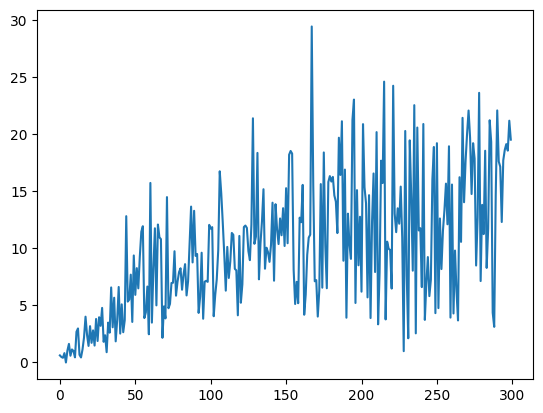

In [7]:
import matplotlib.pyplot as plt

x = np.arange(len(scores))
y = np.array(scores)
plt.plot(x,y)

In [9]:
ddpg.actor.load_state_dict(torch.load('ddpg_step_critic.pth',weights_only=True))

<All keys matched successfully>

In [10]:
import numpy as np

scores = []                         # initialize the score (for each agent)

# ddpg = DDPG(lr=1e-3,device=device,dual_critic=True)

# ddpg.actor.load_state_dict(torch.load('actor.pth',weights_only=True))


brain_name = env.brain_names[0]
brain = env.brains[brain_name]

for i in range(100):
    score = 0
    env_info = env.reset(train_mode=True)[brain_name]
    done = False
    state = env_info.vector_observations[0]
    while not done:
        with torch.no_grad():
            state_t = torch.tensor(state,device=device,dtype=torch.float32)
            actions = ddpg.actor(state_t).cpu().numpy()
            #actions = torch.clip(actions, -1, 1).cpu().numpy()                  # all actions between -1 and 1
        env_info = env.step(actions)[brain_name]           # send all actions to tne environment
        next_state = env_info.vector_observations[0]         # get next state (for eCach agent)
        rewards = env_info.rewards[0]                         # get reward (for each agent)
        done = env_info.local_done[0]                       # see if episode finished
        score += rewards                       # update the score (for each agent)
        state = next_state                               # roll over states to next time step
    scores.append(score)
    print(f"episodes done {i+1}/100", end='\r', flush=True)

print()
print(sum(scores)/100)

episodes done 100/100
27.019999396055937


In [ ]:
/home/swapnil/reacher/Reacher_Linux/Reacher_Linux

In [ ]:
env.close()

In [ ]:
import psutil

def cleanup_zombie_processes():
    for proc in psutil.process_iter(['pid', 'ppid', 'name', 'status']):
        if proc.info['name'] == 'Reacher_One_Lin' and proc.info['status'] == 'zombie':
            print(f"Zombie process detected: {proc.info}")
            parent = psutil.Process(proc.info['ppid'])
            print(f"Terminating parent process: {parent}")
            parent.terminate()

cleanup_zombie_processes()